In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def generate_line_trajectory_delta(elapsed_time: float,
                             start_pos: np.ndarray,
                             end_pos: np.ndarray,
                             duration: float):
    """
    Generate desired position, velocity, and acceleration for minimum jerk trajectory.
    Uses the formula: x(t) = x_0 + [10σ³ - 15σ⁴ + 6σ⁵](x_f - x_0), σ = t/T
    Args:
        elapsed_time: Elapsed time since start
        start_pos: Starting position (3D)
        end_pos: Ending position (3D)
        duration: Total duration T
    Returns:
        Tuple of (position, velocity, acceleration)
    """
    # Clamp time to [0, T]
    t = np.clip(elapsed_time, 0.0, duration)
    sigma = t / duration

    # Position: x(t) = x_0 + [10σ³ - 15σ⁴ + 6σ⁵](x_f - x_0)
    s = 10 * sigma**3 - 15 * sigma**4 + 6 * sigma**5
    x_desired = start_pos + s * (end_pos - start_pos)

    # Velocity: dx/dt = [30σ² - 60σ³ + 30σ⁴] / T * (x_f - x_0)
    ds_dt = (30 * sigma**2 - 60 * sigma**3 + 30 * sigma**4) / duration
    x_dot_desired = ds_dt * (end_pos - start_pos)

    # Acceleration: d²x/dt² = [60σ - 180σ² + 120σ³] / T² * (x_f - x_0)
    d2s_dt2 = (60 * sigma - 180 * sigma**2 + 120 * sigma**3) / (duration**2)
    x_ddot_desired = d2s_dt2 * (end_pos - start_pos)

    return x_desired, x_dot_desired, x_ddot_desired

# generate_line_trajectory_delta(elapsed, self.start_pos, self.end_pos, 5.0) 

start_pos
array([ 0.48679228, -0.00187743,  0.04377018])
end_pos
array([0.5371, 0.    , 0.044 ])

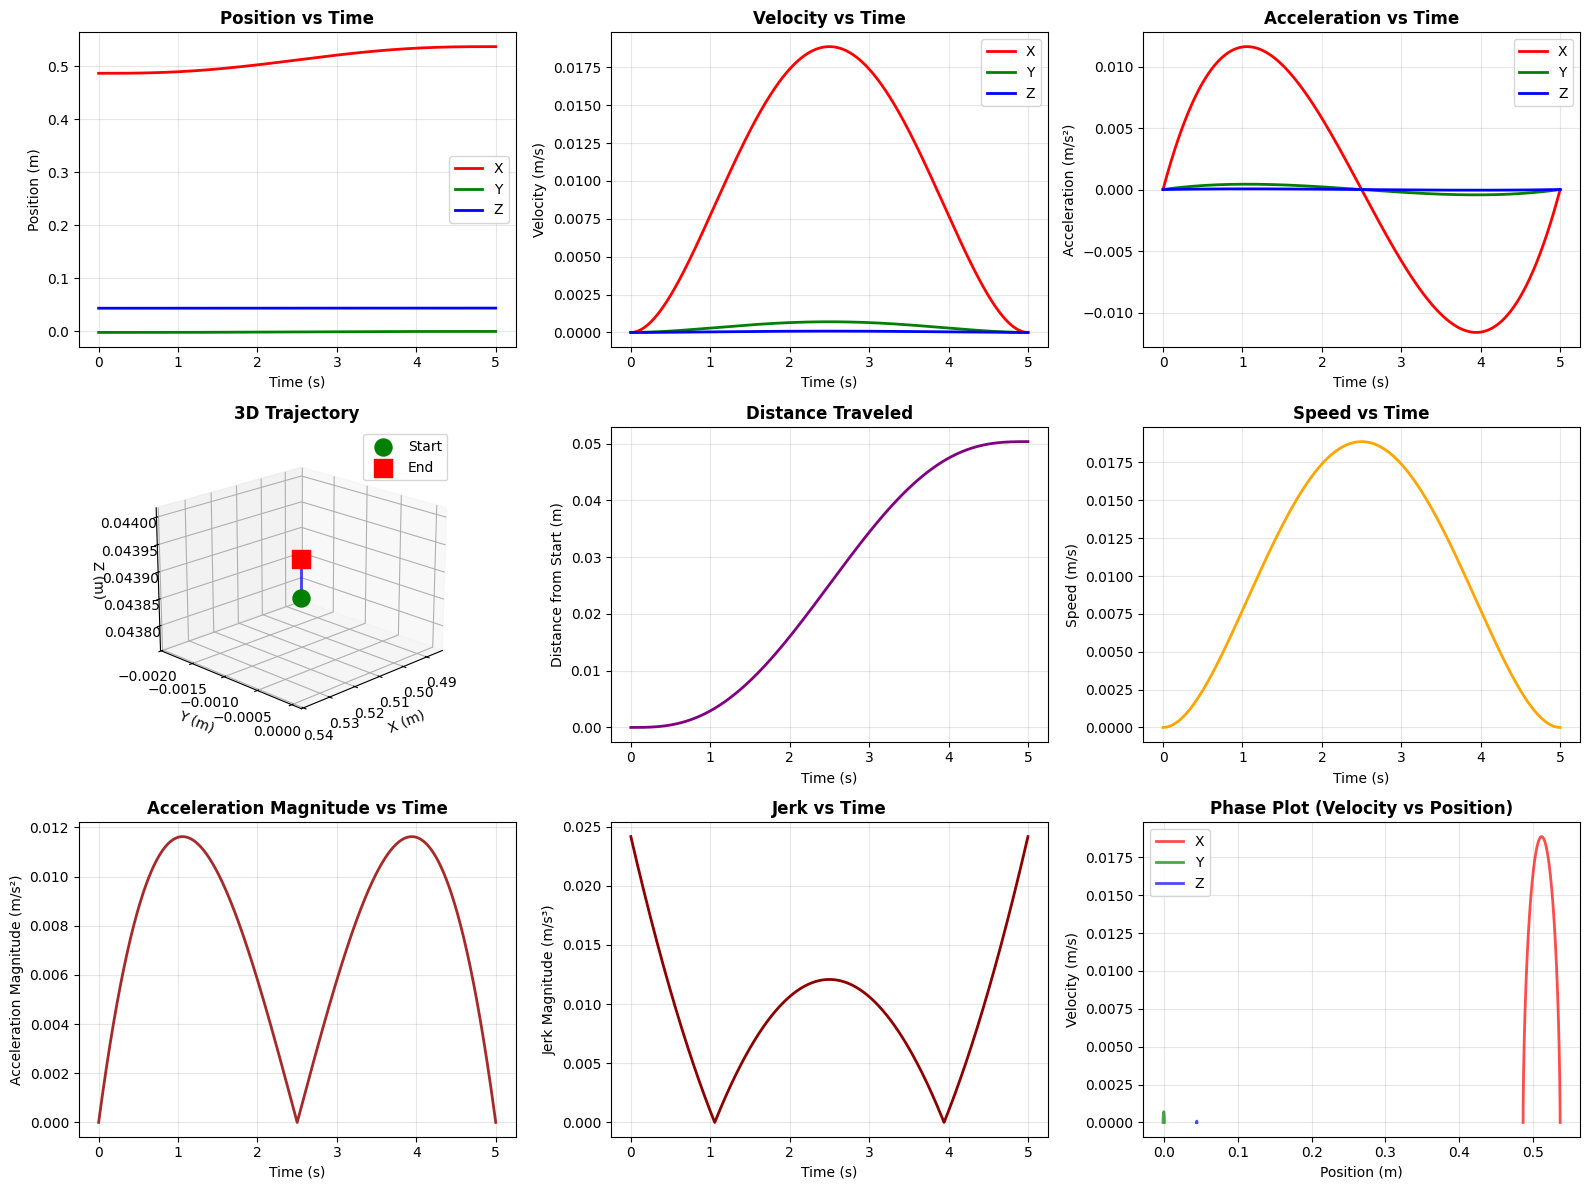


TRAJECTORY STATISTICS
Duration: 5.0 seconds
Time step (dt): 0.001 seconds
Number of samples: 5001

Start position: [ 0.48679228 -0.00187743  0.04377018]
End position: [0.5371 0.     0.044 ]
Total distance: 0.0503 m

Max speed: 0.0189 m/s at t=2.500 s
Max acceleration: 0.0116 m/s² at t=3.943 s
Max jerk: 0.0242 m/s³

Final position: [0.5371 0.     0.044 ]
Final velocity: [0. 0. 0.] (should be ~[0, 0, 0])
Final acceleration: [0. 0. 0.] (should be ~[0, 0, 0])


In [4]:
# Simulation parameters
dt = 0.001  # Time step in seconds
duration = 5.0  # Total duration in seconds
start_pos = np.array([ 0.48679228, -0.00187743,  0.04377018])  # Starting position
end_pos = np.array([0.5371, 0.    , 0.044 ])    # Ending position

# Generate trajectory
time_steps = np.arange(0, duration + dt, dt)
positions = []
velocities = []
accelerations = []

for t in time_steps:
    pos, vel, acc = generate_line_trajectory_delta(t, start_pos, end_pos, duration)
    positions.append(pos)
    velocities.append(vel)
    accelerations.append(acc)

positions = np.array(positions)
velocities = np.array(velocities)
accelerations = np.array(accelerations)

# Create plots
fig = plt.figure(figsize=(16, 12))

# Position plots
ax1 = plt.subplot(3, 3, 1)
ax1.plot(time_steps, positions[:, 0], 'r-', linewidth=2, label='X')
ax1.plot(time_steps, positions[:, 1], 'g-', linewidth=2, label='Y')
ax1.plot(time_steps, positions[:, 2], 'b-', linewidth=2, label='Z')
ax1.set_xlabel('Time (s)', fontsize=10)
ax1.set_ylabel('Position (m)', fontsize=10)
ax1.set_title('Position vs Time', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Velocity plots
ax2 = plt.subplot(3, 3, 2)
ax2.plot(time_steps, velocities[:, 0], 'r-', linewidth=2, label='X')
ax2.plot(time_steps, velocities[:, 1], 'g-', linewidth=2, label='Y')
ax2.plot(time_steps, velocities[:, 2], 'b-', linewidth=2, label='Z')
ax2.set_xlabel('Time (s)', fontsize=10)
ax2.set_ylabel('Velocity (m/s)', fontsize=10)
ax2.set_title('Velocity vs Time', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Acceleration plots
ax3 = plt.subplot(3, 3, 3)
ax3.plot(time_steps, accelerations[:, 0], 'r-', linewidth=2, label='X')
ax3.plot(time_steps, accelerations[:, 1], 'g-', linewidth=2, label='Y')
ax3.plot(time_steps, accelerations[:, 2], 'b-', linewidth=2, label='Z')
ax3.set_xlabel('Time (s)', fontsize=10)
ax3.set_ylabel('Acceleration (m/s²)', fontsize=10)
ax3.set_title('Acceleration vs Time', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 3D trajectory plot
ax4 = plt.subplot(3, 3, 4, projection='3d')
ax4.plot(positions[:, 0], positions[:, 1], positions[:, 2], 'b-', linewidth=2, alpha=0.7)
ax4.scatter(start_pos[0], start_pos[1], start_pos[2], color='green', s=150, label='Start', marker='o')
ax4.scatter(end_pos[0], end_pos[1], end_pos[2], color='red', s=150, label='End', marker='s')
ax4.set_xlabel('X (m)', fontsize=10)
ax4.set_ylabel('Y (m)', fontsize=10)
ax4.set_zlabel('Z (m)', fontsize=10)
ax4.set_title('3D Trajectory', fontsize=12, fontweight='bold')
ax4.legend()
ax4.view_init(elev=20, azim=45)

# Position magnitude
ax5 = plt.subplot(3, 3, 5)
pos_mag = np.linalg.norm(positions - start_pos, axis=1)
ax5.plot(time_steps, pos_mag, 'purple', linewidth=2)
ax5.set_xlabel('Time (s)', fontsize=10)
ax5.set_ylabel('Distance from Start (m)', fontsize=10)
ax5.set_title('Distance Traveled', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Velocity magnitude
ax6 = plt.subplot(3, 3, 6)
vel_mag = np.linalg.norm(velocities, axis=1)
ax6.plot(time_steps, vel_mag, 'orange', linewidth=2)
ax6.set_xlabel('Time (s)', fontsize=10)
ax6.set_ylabel('Speed (m/s)', fontsize=10)
ax6.set_title('Speed vs Time', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

# Acceleration magnitude
ax7 = plt.subplot(3, 3, 7)
acc_mag = np.linalg.norm(accelerations, axis=1)
ax7.plot(time_steps, acc_mag, 'brown', linewidth=2)
ax7.set_xlabel('Time (s)', fontsize=10)
ax7.set_ylabel('Acceleration Magnitude (m/s²)', fontsize=10)
ax7.set_title('Acceleration Magnitude vs Time', fontsize=12, fontweight='bold')
ax7.grid(True, alpha=0.3)

# Jerk (derivative of acceleration)
ax8 = plt.subplot(3, 3, 8)
jerk = np.diff(accelerations, axis=0) / dt
jerk_mag = np.linalg.norm(jerk, axis=1)
ax8.plot(time_steps[:-1], jerk_mag, 'darkred', linewidth=2)
ax8.set_xlabel('Time (s)', fontsize=10)
ax8.set_ylabel('Jerk Magnitude (m/s³)', fontsize=10)
ax8.set_title('Jerk vs Time', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3)

# Phase plot: velocity vs position
ax9 = plt.subplot(3, 3, 9)
ax9.plot(positions[:, 0], velocities[:, 0], 'r-', linewidth=2, label='X', alpha=0.7)
ax9.plot(positions[:, 1], velocities[:, 1], 'g-', linewidth=2, label='Y', alpha=0.7)
ax9.plot(positions[:, 2], velocities[:, 2], 'b-', linewidth=2, label='Z', alpha=0.7)
ax9.set_xlabel('Position (m)', fontsize=10)
ax9.set_ylabel('Velocity (m/s)', fontsize=10)
ax9.set_title('Phase Plot (Velocity vs Position)', fontsize=12, fontweight='bold')
ax9.grid(True, alpha=0.3)
ax9.legend()

plt.tight_layout()
plt.show()

# Print some statistics
print(f"\n{'='*60}")
print("TRAJECTORY STATISTICS")
print(f"{'='*60}")
print(f"Duration: {duration} seconds")
print(f"Time step (dt): {dt} seconds")
print(f"Number of samples: {len(time_steps)}")
print(f"\nStart position: {start_pos}")
print(f"End position: {end_pos}")
print(f"Total distance: {np.linalg.norm(end_pos - start_pos):.4f} m")
print(f"\nMax speed: {np.max(vel_mag):.4f} m/s at t={time_steps[np.argmax(vel_mag)]:.3f} s")
print(f"Max acceleration: {np.max(acc_mag):.4f} m/s² at t={time_steps[np.argmax(acc_mag)]:.3f} s")
print(f"Max jerk: {np.max(jerk_mag):.4f} m/s³")
print(f"\nFinal position: {positions[-1]}")
print(f"Final velocity: {velocities[-1]} (should be ~[0, 0, 0])")
print(f"Final acceleration: {accelerations[-1]} (should be ~[0, 0, 0])")
print(f"{'='*60}")